<a href="https://colab.research.google.com/github/Reshsajee/my-project-resh/blob/main/Copy_of_efficientnet86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
image_dir = "/content/drive/MyDrive/mushroom/mush/data/mh-dataset/images"
label_dir = "/content/drive/MyDrive/mushroom/mush/data/mh-dataset/labels"

In [ ]:
IMG_SIZE = 224

X = []
y = []

image_files = sorted(os.listdir(image_dir))

for img_file in image_files:
    img_path = os.path.join(image_dir, img_file)

    label_file = os.path.splitext(img_file)[0] + ".txt"
    label_path = os.path.join(label_dir, label_file)

    if not os.path.exists(label_path):
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)   # ✅ EfficientNet preprocessing
    X.append(img)

    with open(label_path, 'r') as f:
        label = f.readline().split()[0]
        y.append(int(label))

X = np.array(X)
y = np.array(y)

print("Data Loaded:", X.shape, y.shape)

Data Loaded: (1128, 224, 224, 3) (1128,)


In [ ]:
# 1️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2️⃣ One-hot encoding
y_train = to_categorical(y_train, 3)
y_test = to_categorical(y_test, 3)

# 3️⃣ Compute class weights to fix imbalance
class_weights_raw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)
class_weights = dict(enumerate(class_weights_raw))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.6277128547579299), 1: np.float64(1.3525179856115108), 2: np.float64(1.49800796812749)}


In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# Fit augmentation to training data
datagen.fit(X_train)

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# Classification head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(3, activation='softmax')(x)

# Complete model
model = models.Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    validation_data=(X_test, y_test),
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.8426 - loss: 0.4403 - val_accuracy: 0.8628 - val_loss: 0.3963
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.8570 - loss: 0.4226 - val_accuracy: 0.8584 - val_loss: 0.4788
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8692 - loss: 0.3609 - val_accuracy: 0.8584 - val_loss: 0.5432
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.8670 - loss: 0.3441 - val_accuracy: 0.8407 - val_loss: 0.5150


In [ ]:
# Unfreeze last 50 layers
for layer in base_model.layers[-50:]:
    layer.trainable = True

# Recompile with low learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tuning with early stopping
history_finetune = model.fit(
    datagen.flow(X_train, y_train, batch_size=16),
    validation_data=(X_test, y_test),
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.8126 - loss: 0.5016 - val_accuracy: 0.8584 - val_loss: 0.4175
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.8392 - loss: 0.4634 - val_accuracy: 0.8496 - val_loss: 0.4367
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.8304 - loss: 0.4931 - val_accuracy: 0.8451 - val_loss: 0.4562


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_classes))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes))

8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step
Confusion Matrix:
 [[110   8   2]
 [  5  37  14]
 [  0   3  47]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       120
           1       0.77      0.66      0.71        56
           2       0.75      0.94      0.83        50

    accuracy                           0.86       226
   macro avg       0.82      0.84      0.83       226
weighted avg       0.86      0.86      0.86       226



In [ ]:
from google.colab import files
uploaded = files.upload()  # This opens a file picker

Saving 66.jpeg to 66.jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Predicted Class: Mature


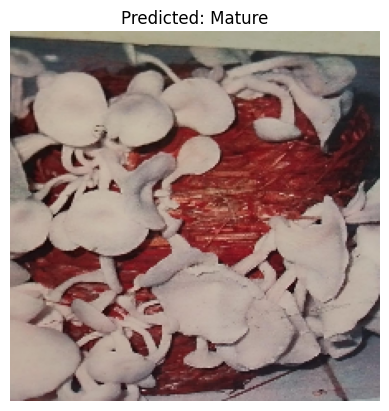

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input

# Function to predict and show the image
def predict_image(img_path):
    # Read image
    img = cv2.imread('/content/66.jpeg')
    img = cv2.resize(img, (224, 224))

    # Preprocess for EfficientNet
    img_input = preprocess_input(img)
    img_input = np.expand_dims(img_input, axis=0)

    # Predict
    pred = model.predict(img_input)
    class_idx = np.argmax(pred)
    class_names = ['Pinhead', 'Growing', 'Mature']

    print(f"Predicted Class: {class_names[class_idx]}")

    # Show image
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Predicted: {class_names[class_idx]}")
    plt.axis('off')
    plt.show()

# Example usage
predict_image("test_mushroom.jpg")  # <-- Replace with the exact filename you uploaded